In [2]:
!pip install -q mediapipe ultralytics onnx onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 76.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 10.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [3]:
import os, json, glob, time, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from ultralytics import YOLO
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from IPython.display import display

RANDOM_SEED = 42
CLASSES = ["bird","boar","dog","dragon","hare","horse",
           "monkey","ox","ram","rat","snake","tiger","zero"]
NUM_CLASSES = len(CLASSES)
DEVICE = [0, 1] # Use both T4 GPUs for YOLO. Use "0" for MLP (single GPU).

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Auto-find the dataset path in Kaggle regardless of folder structure/naming
train_dirs = glob.glob('/kaggle/input/**/train', recursive=True)

if train_dirs:
    EXTRACT_DIR = os.path.dirname(train_dirs[0])
    print(f"✅ Auto-detected dataset path at: {EXTRACT_DIR}")
    print("Contents:", os.listdir(EXTRACT_DIR))
    
    # Read stats if present
    stats_file = os.path.join(EXTRACT_DIR, 'dataset_stats.json')
    if os.path.exists(stats_file):
        with open(stats_file, 'r') as f:
            stats = json.load(f)
            print(f"Loaded dataset stats (created: {stats.get('created_at', 'N/A')})")
else:
    print("❌ ERROR: Could not find 'train' folder under /kaggle/input/. Check dataset attachment.")

✅ Auto-detected dataset path at: /kaggle/input/datasets/hiteshpraj/naruto-dataset/prepared_dataset
Contents: ['class_map.json', 'val', 'dataset_stats.json', 'test', 'train']
Loaded dataset stats (created: 2026-07-23T15:54:42.863750)


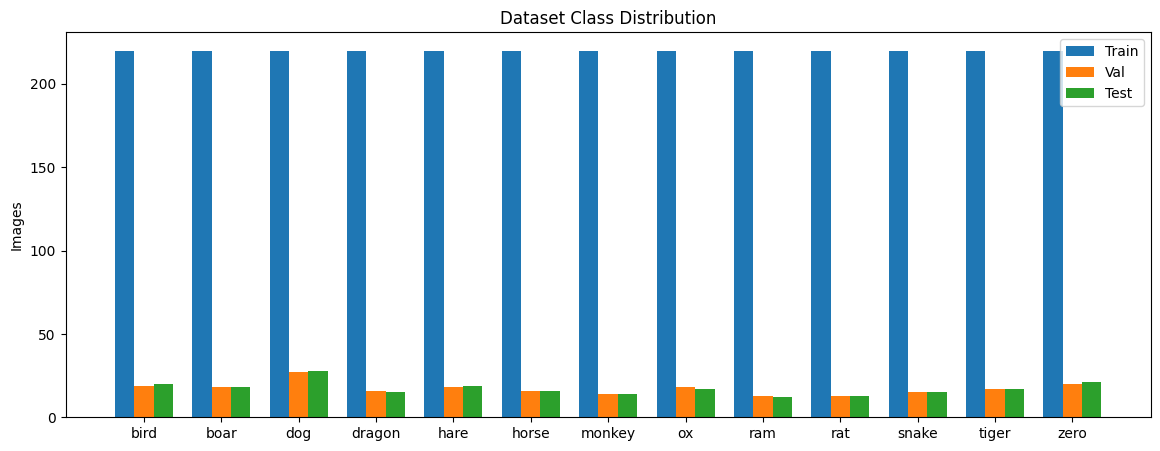

In [5]:
# Distribution Visualization
counts = {'train': [], 'val': [], 'test': []}
for split in counts.keys():
    for c in CLASSES:
        path = os.path.join(EXTRACT_DIR, split, c)
        counts[split].append(len(os.listdir(path)) if os.path.exists(path) else 0)

x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, counts['train'], width, label='Train')
ax.bar(x, counts['val'], width, label='Val')
ax.bar(x + width, counts['test'], width, label='Test')

ax.set_ylabel('Images')
ax.set_title('Dataset Class Distribution')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.legend()
plt.show()

In [6]:
# Train
model_a = YOLO('yolov8n-cls.pt')
results_a = model_a.train(
    data=EXTRACT_DIR,
    epochs=50,
    imgsz=224,
    batch=64,
    device=DEVICE,
    project='naruto_cv',
    name='approach_a_yolo_images',
    patience=10,
    lr0=0.01,
    lrf=0.01,
    warmup_epochs=3,
    weight_decay=0.0005,
    label_smoothing=0.1,
    flipud=0.0, fliplr=0.0, # Disable flips!
    pretrained=True
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/hiteshpraj/naruto-dataset/prepared_dataset, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_wi

In [7]:
# Validate
metrics_a = model_a.val()
acc1_a = metrics_a.top1
acc5_a = metrics_a.top5
print(f"Approach A - Top-1 Accuracy: {acc1_a:.4f}, Top-5: {acc5_a:.4f}")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,451,533 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/input/datasets/hiteshpraj/naruto-dataset/prepared_dataset/train... found 2860 images in 13 classes ✅ 
val: /kaggle/input/datasets/hiteshpraj/naruto-dataset/prepared_dataset/val... found 224 images in 13 classes ✅ 
test: /kaggle/input/datasets/hiteshpraj/naruto-dataset/prepared_dataset/test... found 225 images in 13 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 66.7±33.4 MB/s, size: 82.6 KB)
val: Scanning /kaggle/input/datasets/hiteshpraj/naruto-dataset/prepared_dataset/val... 224 images, 0 corrupt: 100% ━━━━━━━━━━━━ 224/224 2.0Kit/s 0.1s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/hiteshpraj/naruto-dataset/prepared_dataset is not writable, cache not saved.
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 14/14 33.8it/s 0.4s0.0s
                   all      0.9

In [8]:
# Measure Latency
dummy_img = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
# warmup
for _ in range(10): model_a(dummy_img, verbose=False)
    
start = time.time()
for _ in range(100):
    model_a(dummy_img, verbose=False)
latency_a = (time.time() - start) / 100 * 1000 # ms
print(f"Approach A Inference Latency: {latency_a:.2f} ms")

Approach A Inference Latency: 3.58 ms


In [9]:
# The legacy Hands namespace is not included by recent MediaPipe wheels.
# HandLandmarker is the supported replacement.
import urllib.request

HAND_LANDMARKER_MODEL_URL = (
    'https://storage.googleapis.com/mediapipe-models/hand_landmarker/'
    'hand_landmarker/float16/1/hand_landmarker.task'
)
HAND_LANDMARKER_MODEL_PATH = '/kaggle/working/hand_landmarker.task'

if not os.path.exists(HAND_LANDMARKER_MODEL_PATH):
    print('Downloading the MediaPipe HandLandmarker model (one time only)...')
    tmp_model_path = HAND_LANDMARKER_MODEL_PATH + '.download'
    urllib.request.urlretrieve(HAND_LANDMARKER_MODEL_URL, tmp_model_path)
    os.replace(tmp_model_path, HAND_LANDMARKER_MODEL_PATH)

# IMAGE running mode is the direct replacement for static_image_mode=True.
hand_landmarker_options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=HAND_LANDMARKER_MODEL_PATH),
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.5,
)
hand_landmarker = vision.HandLandmarker.create_from_options(hand_landmarker_options)

def extract_normalized_landmarks(img_path):
    img = np.array(Image.open(img_path).convert('RGB'))
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
    results = hand_landmarker.detect(mp_image)
    
    if not results.hand_landmarks:
        return None
    
    # Take the first detected hand, matching the previous behaviour.
    lm_list = results.hand_landmarks[0]
    
    # 1. Extract 21x3
    coords = np.array([[lm.x, lm.y, lm.z] for lm in lm_list]) # (21, 3)
    
    # 2. Normalize (Translation: wrist to origin)
    wrist = coords[0]
    coords = coords - wrist
    
    # 3. Normalize (Scale: max absolute value to 1)
    max_val = np.max(np.abs(coords))
    if max_val > 0:
        coords = coords / max_val
        
    # Return flat 63-D vector
    return coords.flatten()

# Extract for all splits
landmark_data = {'train': [], 'val': [], 'test': []}
dropped_stats = {c: 0 for c in CLASSES}
processed_stats = {c: 0 for c in CLASSES}

for split in ['train', 'val', 'test']:
    print(f"Extracting landmarks for {split}...")
    split_dir = os.path.join(EXTRACT_DIR, split)
    
    for c_idx, c in enumerate(CLASSES):
        c_dir = os.path.join(split_dir, c)
        if not os.path.exists(c_dir): continue
            
        for f in os.listdir(c_dir):
            if not f.endswith('.png'): continue
            path = os.path.join(c_dir, f)
            
            vec = extract_normalized_landmarks(path)
            if vec is not None:
                landmark_data[split].append((vec, c_idx))
                processed_stats[c] += 1
            else:
                dropped_stats[c] += 1

print("Extraction complete!")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784867688.369621     316 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784867688.390254     316 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784867688.428086     316 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Extracting landmarks for train...
Extracting landmarks for val...
Extracting landmarks for test...
Extraction complete!


Total processed: 2854, Total dropped: 455 (13.8%)


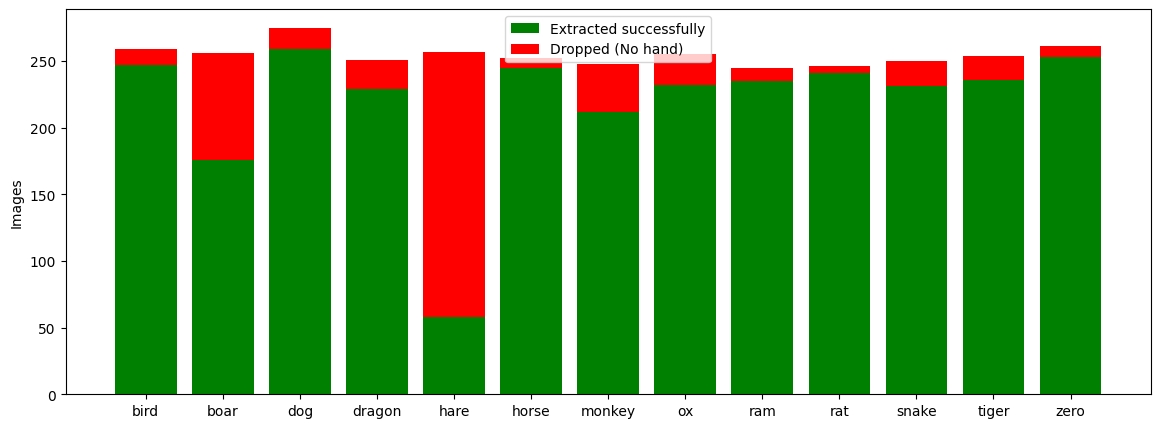

In [10]:
# Landmark Quality Report
total_processed = sum(processed_stats.values())
total_dropped = sum(dropped_stats.values())
print(f"Total processed: {total_processed}, Total dropped: {total_dropped} ({(total_dropped/(total_processed+total_dropped))*100:.1f}%)")

labels = list(processed_stats.keys())
proc = [processed_stats[k] for k in labels]
drop = [dropped_stats[k] for k in labels]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(labels, proc, label='Extracted successfully', color='green')
ax.bar(labels, drop, bottom=proc, label='Dropped (No hand)', color='red')
ax.set_ylabel('Images')
ax.legend()
plt.show()

In [11]:
# Create Landmark Grids for Approach B
GRID_DIR = '/kaggle/working/landmark_grids'
os.makedirs(GRID_DIR, exist_ok=True)

for split in ['train', 'val', 'test']:
    for c in CLASSES:
        os.makedirs(os.path.join(GRID_DIR, split, c), exist_ok=True)
        
    for i, (vec, c_idx) in enumerate(landmark_data[split]):
        # Pad 63 to 64 to reshape to 8x8
        padded = np.pad(vec, (0, 1), mode='constant')
        grid = padded.reshape((8, 8))
        
        # Scale back to 0-255 for image saving
        grid_norm = ((grid + 1.0) / 2.0 * 255.0).clip(0, 255).astype(np.uint8)
        
        img = Image.fromarray(grid_norm, mode='L')
        # Resize to 64x64 using nearest to preserve pure features, or bilinear? Bilinear requested.
        img = img.resize((64, 64), Image.Resampling.BILINEAR)
        img = img.convert('RGB') # YOLO expects RGB
        
        c = CLASSES[c_idx]
        img.save(os.path.join(GRID_DIR, split, c, f"{i}.png"))
print("Landmark grids saved for Approach B.")

/tmp/ipykernel_58/1007430949.py:17: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(grid_norm, mode='L')


Landmark grids saved for Approach B.


In [12]:
# Train
model_b = YOLO('yolov8n-cls.pt')
results_b = model_b.train(
    data=GRID_DIR,
    epochs=80,
    imgsz=64,
    batch=128,
    device=DEVICE,
    project='naruto_cv',
    name='approach_b_yolo_landmarks',
    patience=15,
    lr0=0.005,
    lrf=0.01,
    warmup_epochs=5,
    label_smoothing=0.1,
    flipud=0.0, fliplr=0.0
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/landmark_grids, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask

In [13]:
# Validate
metrics_b = model_b.val()
acc1_b = metrics_b.top1
acc5_b = metrics_b.top5
print(f"Approach B - Top-1 Accuracy: {acc1_b:.4f}, Top-5: {acc5_b:.4f}")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,451,533 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/working/landmark_grids/train... found 2470 images in 13 classes ✅ 
val: /kaggle/working/landmark_grids/val... found 188 images in 13 classes ✅ 
test: /kaggle/working/landmark_grids/test... found 196 images in 13 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 112.2±30.8 MB/s, size: 2.4 KB)
val: Scanning /kaggle/working/landmark_grids/val... 188 images, 0 corrupt: 100% ━━━━━━━━━━━━ 188/188 87.6Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 12/12 49.5it/s 0.2s3s
                   all      0.947          1
Speed: 0.0ms preprocess, 1.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val-2
Approach B - Top-1 Accuracy: 0.9468, Top-5: 1.0000


In [14]:
# Measure Latency (YOLO forward pass only)
dummy_img_b = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
for _ in range(10): model_b(dummy_img_b, verbose=False)
    
start = time.time()
for _ in range(100):
    model_b(dummy_img_b, verbose=False)
latency_b_yolo = (time.time() - start) / 100 * 1000

# Average MediaPipe extraction time
start = time.time()
for _ in range(10):
    extract_normalized_landmarks(os.path.join(EXTRACT_DIR, 'train', CLASSES[0], os.listdir(os.path.join(EXTRACT_DIR, 'train', CLASSES[0]))[0]))
latency_mp = (time.time() - start) / 10 * 1000

latency_b = latency_b_yolo + latency_mp
print(f"Approach B Inference Latency: {latency_b:.2f} ms (MediaPipe: {latency_mp:.2f} + YOLO: {latency_b_yolo:.2f})")

Approach B Inference Latency: 51.45 ms (MediaPipe: 48.54 + YOLO: 2.90)


In [15]:
# Define Model
class HandSignMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, NUM_CLASSES)
        )
        
    def forward(self, x):
        return self.net(x)

mlp = HandSignMLP().cuda()

In [16]:
# DataLoaders
def make_loader(split_data, batch_size=256, shuffle=False):
    if not split_data: return None
    X = torch.tensor(np.stack([item[0] for item in split_data]), dtype=torch.float32)
    y = torch.tensor([item[1] for item in split_data], dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(landmark_data['train'], shuffle=True)
val_loader = make_loader(landmark_data['val'])
test_loader = make_loader(landmark_data['test'])

In [17]:
# Train Loop
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=2)

EPOCHS = 150
best_acc_c = 0.0

train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    mlp.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.cuda(), y.cuda()
        optimizer.zero_grad()
        out = mlp(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    scheduler.step()
    train_losses.append(running_loss / len(train_loader))
    
    # Val
    mlp.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.cuda(), y.cuda()
            out = mlp(X)
            val_loss += criterion(out, y).item()
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            
    val_acc = correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_acc)
    
    if val_acc > best_acc_c:
        best_acc_c = val_acc
        torch.save(mlp.state_dict(), 'best_mlp.pth')
        
    if (epoch+1) % 30 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")

print(f"Approach C - Best Val Accuracy: {best_acc_c:.4f}")

Epoch 030 | Train Loss: 0.7869 | Val Loss: 0.7514 | Val Acc: 0.9255
Epoch 060 | Train Loss: 0.6924 | Val Loss: 0.6672 | Val Acc: 0.9521
Epoch 090 | Train Loss: 0.6762 | Val Loss: 0.6591 | Val Acc: 0.9628
Epoch 120 | Train Loss: 0.6535 | Val Loss: 0.6505 | Val Acc: 0.9628
Epoch 150 | Train Loss: 0.6381 | Val Loss: 0.6422 | Val Acc: 0.9681
Approach C - Best Val Accuracy: 0.9681


In [18]:
# Evaluate Test Set
mlp.load_state_dict(torch.load('best_mlp.pth'))
mlp.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        out = mlp(X.cuda())
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

acc1_c = accuracy_score(all_labels, all_preds)
print(f"Approach C - Top-1 Accuracy (Test Set): {acc1_c:.4f}")

Approach C - Top-1 Accuracy (Test Set): 0.9694


In [19]:
# Measure Latency
dummy_vec = torch.randn(1, 63).cuda()
for _ in range(10): mlp(dummy_vec)
start = time.time()
for _ in range(100): mlp(dummy_vec)
latency_c_mlp = (time.time() - start) / 100 * 1000

latency_c = latency_c_mlp + latency_mp
print(f"Approach C Inference Latency: {latency_c:.2f} ms (MediaPipe: {latency_mp:.2f} + MLP: {latency_c_mlp:.2f})")

Approach C Inference Latency: 49.14 ms (MediaPipe: 48.54 + MLP: 0.59)


In [20]:
# Comparison Table
import pandas as pd

data = {
    'Metric': ['Top-1 Accuracy', 'Inference Latency (ms)', 'Requires MediaPipe?'],
    'App A (YOLO Images)': [f"{acc1_a:.4f}", f"{latency_a:.2f}", "No"],
    'App B (YOLO Landmarks)': [f"{acc1_b:.4f}", f"{latency_b:.2f}", "Yes"],
    'App C (MLP Landmarks)': [f"{acc1_c:.4f}", f"{latency_c:.2f}", "Yes"]
}
df = pd.DataFrame(data)
display(df)

,Metric,App A (YOLO Images),App B (YOLO Landmarks),App C (MLP Landmarks)
0,Top-1 Accuracy,0.9955,0.9468,0.9694
1,Inference Latency (ms),3.58,51.45,49.14
2,Requires MediaPipe?,No,Yes,Yes


In [22]:
# Select Winner Based on Accuracy
best_approach = None
best_acc = max(acc1_a, acc1_b, acc1_c)

if best_acc == acc1_a:
    best_approach = 'A'
    print("🏆 Winner is Approach A!")
    path = model_a.export(format='onnx', imgsz=224)
    shutil.copy(path, '/kaggle/working/best_model_A.onnx')
    
elif best_acc == acc1_b:
    best_approach = 'B'
    print("🏆 Winner is Approach B!")
    path = model_b.export(format='onnx', imgsz=64)
    shutil.copy(path, '/kaggle/working/best_model_B.onnx')
    
else:
    best_approach = 'C'
    print("🏆 Winner is Approach C!")
    dummy_input = torch.randn(1, 63).cuda()
    torch.onnx.export(mlp, dummy_input, '/kaggle/working/best_model_C.onnx',
                      export_params=True, opset_version=14, do_constant_folding=True,
                      input_names=['input'], output_names=['output'])

print("✅ ONNX model saved to /kaggle/working/. You can download it from the Output sidebar.")


🏆 Winner is Approach A!
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/classify/naruto_cv/approach_a_yolo_images/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 13) (2.9 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 339ms
Prepared 1 package in 69ms
Installed 1 package in 12ms
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.7s, saved as '/kaggle/working/runs/classify/naruto_cv/approach_a_yolo_images/weig